**Considering two things in glucose env only:**
1. Excretion profiles in outlier samples
2. tRNAChargingReactions; does the flux through these reactions (and thus synthesis of amino acids) vary?

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [22]:
import pandas as pd
import scripts.EDA.data_prep2 as prep

In [23]:
data = pd.read_pickle(DATA/'ml_datasets_ARCHIVE/all_raw_samples.pkl')

## 1. Outlier secretion profiles

In [ ]:

data['outliers_2'] = data['lipid_biomass_to_biomass'] / data['biomass_dilution']
data['outliers_2'] = data["outliers_2"].round(3)

deviating_rows = data[data["outliers_2"] != 0.134]


glc_data = data[data['source']=='glc']

In [5]:
glc_flux = pd.read_pickle('/triumvirate/home/celinaha/LO_sampling/optimal_runs/optimal_EX_glc__D_e_EX_nh4_e.pkl')

In [45]:
glc_out = glc_data.loc[glc_data['outlier']==1, "sample"]
glc_normal = glc_data.loc[glc_data['outlier']==0, "sample"]

In [63]:
glc_outliers = glc_data[glc_data["outlier"]==1]

**Exchange reactions:**

In [31]:
glc_ex = glc_flux[glc_flux["reaction"].str.startswith("EX_", na=False)].copy()
glc_ex.drop(columns='flux', inplace=True)

glc_ex.to_csv('ex_rxns.csv', index=False)

In [32]:
glc_samples = prep.get_samples(path='/triumvirate/home/celinaha/LHS_sampling/lhs_glc/results/flux')
glc = prep.merge_samples(glc_samples, '/triumvirate/home/celinaha/thesis_files/ex_rxns.csv', substrate='glc')

In [ ]:
sec = glc.set_index("reaction").T
sec = sec.loc[:, (sec > 0).any(axis=0)]

In [49]:
sec_outliers = sec.loc[glc_out]
sec_normal = sec.loc[glc_normal]

In [57]:
sec_normal.describe().T

,count,mean,std,min,25%,50%,75%,max
reaction,,,,,,,,
EX_12ppd__R_e,689.0,1.716599e+00,5.417640e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.405459e+01
EX_5mtr_e,689.0,5.138885e-05,4.539530e-05,4.537892e-07,1.498523e-05,3.598704e-05,8.069308e-05,1.725457e-04
EX_ac_e,689.0,2.128985e-01,1.138777e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.335664e+01
EX_acald_e,689.0,1.559110e-05,2.201770e-05,0.000000e+00,0.000000e+00,5.122675e-06,2.301925e-05,9.032359e-05
EX_co2_e,689.0,3.099354e+01,3.145602e+01,6.734704e-02,2.217883e+00,2.107307e+01,5.314763e+01,1.076814e+02
EX_dha_e,689.0,4.229368e+01,3.314744e+01,0.000000e+00,1.583963e+01,4.009377e+01,6.249945e+01,1.425733e+02
EX_eca4colipa_e,689.0,2.184088e-27,5.732970e-26,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.504836e-24
EX_enter_e,689.0,5.628914e-28,1.477523e-26,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.878322e-25
EX_etoh_e,689.0,2.458646e-03,6.442987e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.691211e+00


In [56]:
sec_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
reaction,,,,,,,,
EX_12ppd__R_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_5mtr_e,14.0,6.396631e-05,3.835399e-05,1.833298e-08,3.737107e-05,5.910966e-05,8.903326e-05,1.333182e-04
EX_ac_e,14.0,7.170484e+00,6.133843e+00,0.000000e+00,1.023363e+00,7.577971e+00,1.124831e+01,1.748323e+01
EX_acald_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_co2_e,14.0,6.165506e+00,5.913299e+00,8.817323e-02,2.836324e-01,6.205876e+00,1.111908e+01,1.602023e+01
EX_dha_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_eca4colipa_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_enter_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_etoh_e,14.0,2.088753e+00,3.496102e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.993700e+00,1.002031e+01


In [138]:
sec.columns

sec["biomass_dilution"] = glc_data["biomass_dilution"].tolist()

In [200]:
sec.columns

Index(['EX_12ppd__R_e', 'EX_5mtr_e', 'EX_ac_e', 'EX_acald_e', 'EX_co2_e',
       'EX_dha_e', 'EX_eca4colipa_e', 'EX_enter_e', 'EX_etoh_e', 'EX_fe3_e',
       'EX_for_e', 'EX_glyc__R_e', 'EX_glyclt_e', 'EX_h_e', 'EX_h2o_e',
       'EX_lac__D_e', 'EX_lipa_e', 'EX_meoh_e', 'EX_pheme_e', 'EX_pyr_e',
       'EX_succ_e', 'biomass_dilution'],
      dtype='object', name='reaction')

In [117]:
sec_outliers["o2_e_shadow"] = glc_outliers["o2_e_shadow"].tolist()
sec_outliers["source_shadow"] = glc_outliers["source_shadow"].tolist()
sec_outliers["alpha"] = - (sec_outliers["source_shadow"]/sec_outliers["o2_e_shadow"])

sec_outliers["biomass_dilution"] = glc_outliers["biomass_dilution"].tolist()

In [211]:
sec_prof = sec_outliers[["biomass_dilution", "o2_e_shadow", "source_shadow", "alpha", 'EX_5mtr_e', 'EX_ac_e','EX_etoh_e',
       'EX_for_e', 'EX_glyclt_e', "EX_meoh_e"]]

sec_prof.sort_values(by="alpha", ascending=False)

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_5mtr_e,EX_ac_e,EX_etoh_e,EX_for_e,EX_glyclt_e,EX_meoh_e
glc_sample_334,0.000520,7.366932e-08,-0.000692,9389.309800,1.833298e-08,0.000000,0.000000,0.000000,0.000000,2.120647e-13
glc_sample_679,0.564255,-8.584021e-04,-0.000305,-0.355722,8.162992e-05,15.664559,10.020313,29.417622,0.000377,2.497115e-07
glc_sample_415,0.642172,-7.227430e-04,-0.000272,-0.376391,1.120391e-04,17.483226,8.952316,29.588104,0.000430,3.234396e-07
glc_sample_285,0.555374,-7.966844e-04,-0.000331,-0.415593,6.806318e-05,13.585332,4.933452,23.311299,0.000372,2.419130e-07
glc_sample_152,0.385353,-9.936895e-04,-0.000434,-0.436906,2.431259e-05,8.455025,2.017283,15.474534,0.000258,1.164666e-07
glc_sample_436,0.478870,-8.627490e-04,-0.000384,-0.444529,4.369411e-05,11.064913,3.319172,19.586711,0.000320,1.798548e-07
glc_sample_563,0.753315,-6.402248e-04,-0.000288,-0.449702,1.333182e-04,8.951878,0.000000,0.401266,0.000504,4.450878e-07
glc_sample_572,0.650382,-7.295642e-04,-0.000379,-0.519592,9.150105e-05,11.309438,0.000000,11.998711,0.000435,3.317624e-07
glc_sample_373,0.626846,-7.500258e-04,-0.000401,-0.534313,7.431632e-05,6.700918,0.000000,1.767519,0.000419,3.081847e-07
glc_sample_269,0.441987,-9.131616e-04,-0.000572,-0.626517,2.851162e-05,4.866028,0.000000,3.981497,0.000296,1.532164e-07


In [192]:
sec.columns

Index(['EX_12ppd__R_e', 'EX_5mtr_e', 'EX_ac_e', 'EX_acald_e', 'EX_co2_e',
       'EX_dha_e', 'EX_eca4colipa_e', 'EX_enter_e', 'EX_etoh_e', 'EX_fe3_e',
       'EX_for_e', 'EX_glyc__R_e', 'EX_glyclt_e', 'EX_h_e', 'EX_h2o_e',
       'EX_lac__D_e', 'EX_lipa_e', 'EX_meoh_e', 'EX_pheme_e', 'EX_pyr_e',
       'EX_succ_e', 'biomass_dilution'],
      dtype='object', name='reaction')

In [ ]:
sec_prof["EX_glc__D_e"] = glc_outliers["EX_glc__D_e"].tolist()
sec_prof["EX_o2_e"] = glc_outliers["EX_o2_e"].tolist()
sec_prof["EX_nh4_e"] = glc_outliers["EX_nh4_e"].tolist()

In [198]:
sec_prof[["biomass_dilution", "o2_e_shadow", "source_shadow", "alpha", "EX_o2_e", "EX_glc__D_e", "EX_nh4_e", 'EX_etoh_e']]

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_o2_e,EX_glc__D_e,EX_nh4_e,EX_etoh_e
glc_sample_152,0.385353,-9.936895e-04,-0.000434,-0.436906,-1.596374,-9.200463,-2.341014,2.017283
glc_sample_269,0.441987,-9.131616e-04,-0.000572,-0.626517,-4.048472,-7.049585,-2.613104,0.000000
glc_sample_277,0.720808,-6.929262e-04,-0.000901,-1.300687,-11.690847,-8.470784,-6.426609,0.000000
glc_sample_285,0.555374,-7.966844e-04,-0.000331,-0.415593,-3.087152,-14.364875,-4.730991,4.933452
glc_sample_288,0.404950,-1.015586e-02,-0.057792,-5.690486,-7.068314,-4.571650,-3.734376,0.000000
glc_sample_334,0.000520,7.366932e-08,-0.000692,9389.309800,-33.382845,-0.054239,-0.010898,0.000000
glc_sample_373,0.626846,-7.500258e-04,-0.000401,-0.534313,-7.442252,-9.348580,-4.926492,0.000000
glc_sample_415,0.642172,-7.227430e-04,-0.000272,-0.376391,-3.915147,-18.514742,-6.798350,8.952316
glc_sample_436,0.478870,-8.627490e-04,-0.000384,-0.444529,-2.321342,-11.868519,-3.491867,3.319172
glc_sample_563,0.753315,-6.402248e-04,-0.000288,-0.449702,-10.663566,-10.978559,-7.431143,0.000000


In [205]:
sec_alpha = sec.copy()
sec_alpha["o2_e_shadow"] = glc_data["o2_e_shadow"].tolist()
sec_alpha["source_shadow"] = glc_data["source_shadow"].tolist()

sec_alpha["alpha"] = - (sec_alpha["source_shadow"]/sec_alpha["o2_e_shadow"])

sec_alpha["EX_o2_e"] = glc_data["EX_o2_e"].tolist()
sec_alpha["EX_glc__D_e"] = glc_data["EX_glc__D_e"].tolist()

In [206]:
sec_alpha =  sec_alpha[["biomass_dilution", "o2_e_shadow", "source_shadow", "alpha", "EX_o2_e", "EX_glc__D_e", "EX_glyclt_e", "EX_for_e"]]

In [209]:
sec_alpha[sec_alpha["EX_for_e"]>0]

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_o2_e,EX_glc__D_e,EX_glyclt_e,EX_for_e
glc_sample_47,0.689094,-0.000337,-0.000050,-0.149408,-5.667054,-18.868406,0.000518,17.977390
glc_sample_120,0.604917,-0.000134,0.000028,0.212282,-0.753188,-29.903701,0.000451,1.425585
glc_sample_152,0.385353,-0.000994,-0.000434,-0.436906,-1.596374,-9.200463,0.000258,15.474534
glc_sample_154,0.673592,-0.000243,-0.000014,-0.058947,-4.618874,-21.295859,0.000505,11.505725
glc_sample_269,0.441987,-0.000913,-0.000572,-0.626517,-4.048472,-7.049585,0.000296,3.981497
glc_sample_285,0.555374,-0.000797,-0.000331,-0.415593,-3.087152,-14.364875,0.000372,23.311299
glc_sample_373,0.626846,-0.000750,-0.000401,-0.534313,-7.442252,-9.348580,0.000419,1.767519
glc_sample_415,0.642172,-0.000723,-0.000272,-0.376391,-3.915147,-18.514742,0.000430,29.588104
glc_sample_436,0.478870,-0.000863,-0.000384,-0.444529,-2.321342,-11.868519,0.000320,19.586711
glc_sample_437,0.700903,-0.000255,-0.000016,-0.061504,-6.162796,-20.200672,0.000527,2.747700


In [186]:
sec_alpha.sort_values(by="alpha", ascending=True)

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_o2_e,EX_glc__D_e,EX_glyclt_e,EX_for_e
glc_sample_516,0.387039,3.474888e-08,0.000039,-1132.348176,-4.920057,-67.065798,0.000259,0.0
glc_sample_575,0.410414,8.810881e-08,0.000042,-474.528523,-5.249740,-64.442433,0.000275,0.0
glc_sample_219,0.063917,3.743304e-08,0.000007,-181.342217,-3.397082,-100.373187,0.000043,0.0
glc_sample_111,0.085235,6.204964e-08,0.000009,-146.122195,-3.827346,-98.072712,0.000057,0.0
glc_sample_76,0.502765,3.594253e-07,0.000052,-143.666762,-6.700293,-54.309614,0.000336,0.0
...,...,...,...,...,...,...,...,...
glc_sample_29,0.089700,1.579953e-06,-0.063136,39960.806176,-59.904717,-1.024393,0.000000,0.0
glc_sample_525,0.052042,9.867323e-07,-0.062579,63420.056266,-14.155389,-0.614670,0.000000,0.0
glc_sample_461,0.038973,7.344922e-07,-0.062686,85346.318305,-7.894290,-0.472677,0.000000,0.0
glc_sample_578,0.016776,4.035230e-07,-0.061919,153445.427033,-21.298937,-0.231526,0.000000,0.0


**Overall secretion profiles for the rest:**

In [212]:
ac_samples = prep.get_samples(path='/triumvirate/home/celinaha/LHS_sampling/lhs_ac/results/flux')
ac = prep.merge_samples(ac_samples, '/triumvirate/home/celinaha/thesis_files/ex_rxns.csv', substrate='ac')

In [241]:
sec = ac.set_index("reaction").T
sec = sec.loc[:, (sec > 0).any(axis=0)]

ac_data = data[data['source']=='ac']
ac_out = ac_data.loc[ac_data['outlier']==1, "sample"]
ac_normal = ac_data.loc[ac_data['outlier']==0, "sample"]

ac_outliers =  ac_data[ac_data['outlier']==1]
ac_norm =  ac_data[ac_data['outlier']==0]

sec_outliers = sec.loc[ac_out]
sec_normal = sec.loc[ac_normal]

In [249]:
sec_outliers["o2_e_shadow"] = ac_outliers["o2_e_shadow"].tolist()
sec_outliers["source_shadow"] = ac_outliers["source_shadow"].tolist()
sec_outliers["alpha"] = - (sec_outliers["source_shadow"]/sec_outliers["o2_e_shadow"])

In [243]:
sec_normal["o2_e_shadow"] = ac_norm["o2_e_shadow"].tolist()
sec_normal["source_shadow"] = ac_norm["source_shadow"].tolist()
sec_normal["alpha"] = - (sec_normal["source_shadow"]/sec_normal["o2_e_shadow"])

In [214]:
sec.columns

Index(['EX_5mtr_e', 'EX_acald_e', 'EX_ala__D_e', 'EX_ala__L_e', 'EX_cit_e',
       'EX_co2_e', 'EX_crn__D_e', 'EX_etoh_e', 'EX_fe3_e', 'EX_h2o_e',
       'EX_lac__D_e', 'EX_lipa_e', 'EX_meoh_e', 'EX_no3_e', 'EX_o16a4colipa_e',
       'EX_pyr_e'],
      dtype='object', name='reaction')

In [216]:
sec_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
reaction,,,,,,,,
EX_5mtr_e,42.0,2.286730e-05,2.762041e-05,3.606369e-07,4.059323e-06,1.085727e-05,3.509709e-05,1.108513e-04
EX_acald_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_ala__D_e,42.0,2.941163e-03,2.213618e-03,0.000000e+00,1.321745e-03,2.354147e-03,4.567090e-03,8.364864e-03
EX_ala__L_e,42.0,6.962097e+00,5.437800e+00,0.000000e+00,2.630168e+00,6.391556e+00,1.089555e+01,1.892687e+01
EX_cit_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_co2_e,42.0,3.132253e+01,1.275434e+01,8.844744e+00,2.250543e+01,3.112264e+01,3.912779e+01,5.931011e+01
EX_crn__D_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_etoh_e,42.0,1.205821e+01,9.111781e+00,2.835570e-06,5.180387e+00,1.077645e+01,1.840980e+01,3.325101e+01
EX_fe3_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [258]:
outliers = data[data["outlier"]==1]

outliers[outliers["source"]=="lcts"]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_ac_e,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow
1498,lcts_sample_313,0.032228,0.000103,0.000623,0.004450,0.000001,0.004366,0.009876,0.001883,0.000028,...,0.0,-99.441953,0.0,0.0,0.0,0.0,lcts,1,0.000006,0.000003
1626,lcts_sample_441,0.199207,0.001191,0.007241,0.051706,0.000055,0.022481,0.064986,0.012385,0.000314,...,0.0,-95.360109,0.0,0.0,0.0,0.0,lcts,1,0.000028,0.000022
1693,lcts_sample_508,0.152720,0.000791,0.004808,0.034336,0.000033,0.019697,0.049196,0.009376,0.000181,...,0.0,-88.575445,0.0,0.0,0.0,0.0,lcts,1,0.000027,0.000017


## 2. tRNAChargingReactions

In [34]:
glc_subset = glc_flux[
    glc_flux["reaction"].str.contains("charging_tRNA_", na=False)
    | glc_flux["reaction"].isin([
        "biomass_dilution",
        "EX_glc__D_e",
        "EX_o2_e"
    ])
].copy()

In [43]:
aminos =  ['NaN',
 'NaN',
 'NaN',
 'generic_tRNA_AUC_ile__L_c',
 'generic_tRNA_AUU_ile__L_c',
 'generic_tRNA_GCA_ala__L_c',
 'generic_tRNA_GCG_ala__L_c',
 'generic_tRNA_GCU_ala__L_c',
 'generic_tRNA_GAC_asp__L_c',
 'generic_tRNA_GAU_asp__L_c',
 'generic_tRNA_GAC_asp__L_c',
 'generic_tRNA_GAU_asp__L_c',
 'generic_tRNA_ACG_thr__L_c',
 'generic_tRNA_AGA_arg__L_c',
 'generic_tRNA_CAA_gln__L_c',
 'generic_tRNA_CAA_gln__L_c',
 'generic_tRNA_AUG_met__L_c',
 'generic_tRNA_CAG_gln__L_c',
 'generic_tRNA_CAG_gln__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CUA_leu__L_c',
 'generic_tRNA_AUG_met__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_UCC_ser__L_c',
 'generic_tRNA_UCU_ser__L_c',
 'generic_tRNA_UCU_ser__L_c',
 'generic_tRNA_UCA_ser__L_c',
 'generic_tRNA_UCG_ser__L_c',
 'generic_tRNA_UCC_ser__L_c',
 'generic_tRNA_UCU_ser__L_c',
 'generic_tRNA_UAC_tyr__L_c',
 'generic_tRNA_UAU_tyr__L_c',
 'generic_tRNA_UAC_tyr__L_c',
 'generic_tRNA_UAU_tyr__L_c',
 'generic_tRNA_GUC_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_GUC_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_UUG_leu__L_c',
 'generic_tRNA_UUA_leu__L_c',
 'generic_tRNA_UGC_cys__L_c',
 'generic_tRNA_UGU_cys__L_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_UCG_ser__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_CCC_pro__L_c',
 'generic_tRNA_CCU_pro__L_c',
 'generic_tRNA_AGG_arg__L_c',
 'generic_tRNA_GCC_ala__L_c',
 'generic_tRNA_GCC_ala__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_AUA_ile__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_AGC_ser__L_c',
 'generic_tRNA_AGU_ser__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_GGG_gly_c',
 'generic_tRNA_UUC_phe__L_c',
 'generic_tRNA_UUU_phe__L_c',
 'generic_tRNA_AUA_ile__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_CUC_leu__L_c',
 'generic_tRNA_CUU_leu__L_c',
 'generic_tRNA_ACC_thr__L_c',
 'generic_tRNA_ACU_thr__L_c',
 'generic_tRNA_GCA_ala__L_c',
 'generic_tRNA_GCG_ala__L_c',
 'generic_tRNA_GCU_ala__L_c',
 'generic_tRNA_AUC_ile__L_c',
 'generic_tRNA_AUU_ile__L_c',
 'generic_tRNA_CCG_pro__L_c',
 'generic_tRNA_UGA_cys__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_GAC_asp__L_c',
 'generic_tRNA_GAU_asp__L_c',
 'generic_tRNA_UGG_trp__L_c',
 'generic_tRNA_CGG_arg__L_c',
 'generic_tRNA_CAC_his__L_c',
 'generic_tRNA_CAU_his__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CCG_pro__L_c',
 'generic_tRNA_CCU_pro__L_c',
 'generic_tRNA_CCA_pro__L_c',
 'generic_tRNA_AUC_ile__L_c',
 'generic_tRNA_AUU_ile__L_c',
 'generic_tRNA_GCA_ala__L_c',
 'generic_tRNA_GCG_ala__L_c',
 'generic_tRNA_GCU_ala__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_ACU_thr__L_c',
 'generic_tRNA_ACA_thr__L_c',
 'generic_tRNA_ACG_thr__L_c',
 'generic_tRNA_UAC_tyr__L_c',
 'generic_tRNA_UAU_tyr__L_c',
 'generic_tRNA_GGA_gly_c',
 'generic_tRNA_ACC_thr__L_c',
 'generic_tRNA_ACU_thr__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_UUC_phe__L_c',
 'generic_tRNA_UUU_phe__L_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_UUG_leu__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CUG_leu__L_c']

In [42]:
glc_subset["amino_acid"] = aminos

In [46]:
# glc_subset.drop(columns="flux", inplace=True)
glc_subset.to_csv("aa_template.csv", index=False)

In [7]:
meta_cols = ["reaction", "amino_acid"]
flux_cols = glc.columns[2:]

# keep first 3 rows separately
first_three = glc.iloc[:3][["reaction", *flux_cols]].copy()
first_three = first_three.rename(columns={"reaction": "feature"})

# charging rows only
charging = glc[glc["reaction"].str.startswith("charging", na=False)].copy()

# extract only amino acid from: generic_tRNA_codon_aminoacid_c
charging["feature"] = charging["amino_acid"].str.replace(
    r"^generic_tRNA_[^_]+_",
    "",
    regex=True
)

# aggregate so each amino acid appears once
aa_agg = (
    charging
    .groupby("feature", as_index=False)[flux_cols]
    .sum()
)

# combine first 3 reactions + amino acids
combined = pd.concat(
    [first_three[["feature", *flux_cols]], aa_agg],
    ignore_index=True
)

# transpose: FBA simulations as rows, features as columns
glc_transposed = (
    combined
    .set_index("feature")
    .T
    .reset_index()
    .rename(columns={"index": "sample"})
)

In [8]:
glc_transposed

feature,sample,biomass_dilution,EX_glc__D_e,EX_o2_e,ala__L_c,arg__L_c,asn__L_c,asp__L_c,cys__L_c,gln__L_c,...,leu__L_c,lys__L_c,met__L_c,phe__L_c,pro__L_c,ser__L_c,thr__L_c,trp__L_c,tyr__L_c,val__L_c
0,glc_sample_0,0.096826,-96.553068,-1.269566,0.066600,0.028667,0.028694,0.037881,0.004957,0.024587,...,0.057845,0.031629,0.017458,0.022148,0.019343,0.031572,0.032434,0.007480,0.019649,0.042367
1,glc_sample_1,0.384489,-56.251240,-29.741378,0.244671,0.115268,0.105136,0.140396,0.020067,0.093841,...,0.218499,0.123644,0.065970,0.082016,0.076571,0.120806,0.122118,0.026272,0.069345,0.164932
2,glc_sample_2,0.206175,-35.183865,-89.002174,0.132206,0.061310,0.059092,0.076931,0.012241,0.051010,...,0.118534,0.067303,0.036453,0.046263,0.043390,0.066123,0.067703,0.014485,0.039408,0.089686
3,glc_sample_3,0.130626,-53.816171,-74.958210,0.085920,0.038613,0.039225,0.050906,0.007200,0.032772,...,0.076090,0.043002,0.023373,0.030092,0.026667,0.042851,0.043752,0.009550,0.026420,0.056679
4,glc_sample_4,0.026425,-12.129429,-108.072299,0.017524,0.007428,0.009299,0.011460,0.001292,0.006793,...,0.015073,0.008567,0.004824,0.006626,0.005120,0.008858,0.009228,0.002086,0.006668,0.010990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698,glc_sample_698,0.152847,-52.926584,-72.408117,0.100121,0.045191,0.045539,0.059202,0.008387,0.038237,...,0.088733,0.050164,0.027243,0.034972,0.031135,0.049901,0.050926,0.011103,0.030633,0.066182
699,glc_sample_699,0.667365,-22.221855,-4.226421,0.413377,0.204414,0.163595,0.224864,0.036858,0.160447,...,0.373759,0.211989,0.111811,0.134865,0.136319,0.204463,0.200354,0.042945,0.105642,0.291482
700,glc_sample_700,0.022425,-58.984239,-86.031277,0.015062,0.006633,0.007001,0.009021,0.001258,0.005711,...,0.013296,0.007499,0.004092,0.005340,0.004624,0.007537,0.007711,0.001693,0.004745,0.009836
701,glc_sample_701,0.017017,-44.447625,-107.237360,0.011317,0.005060,0.005226,0.006712,0.001034,0.004321,...,0.010088,0.005702,0.003113,0.004046,0.003634,0.005693,0.005848,0.001265,0.003527,0.007536


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

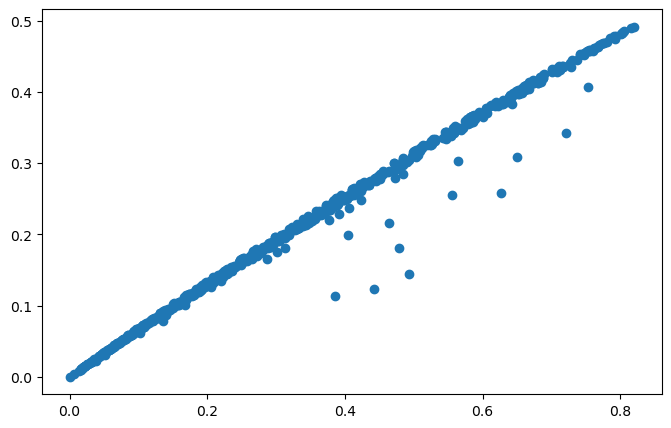

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(glc_transposed.iloc[:,1], glc_transposed.iloc[:,4])
plt.show()


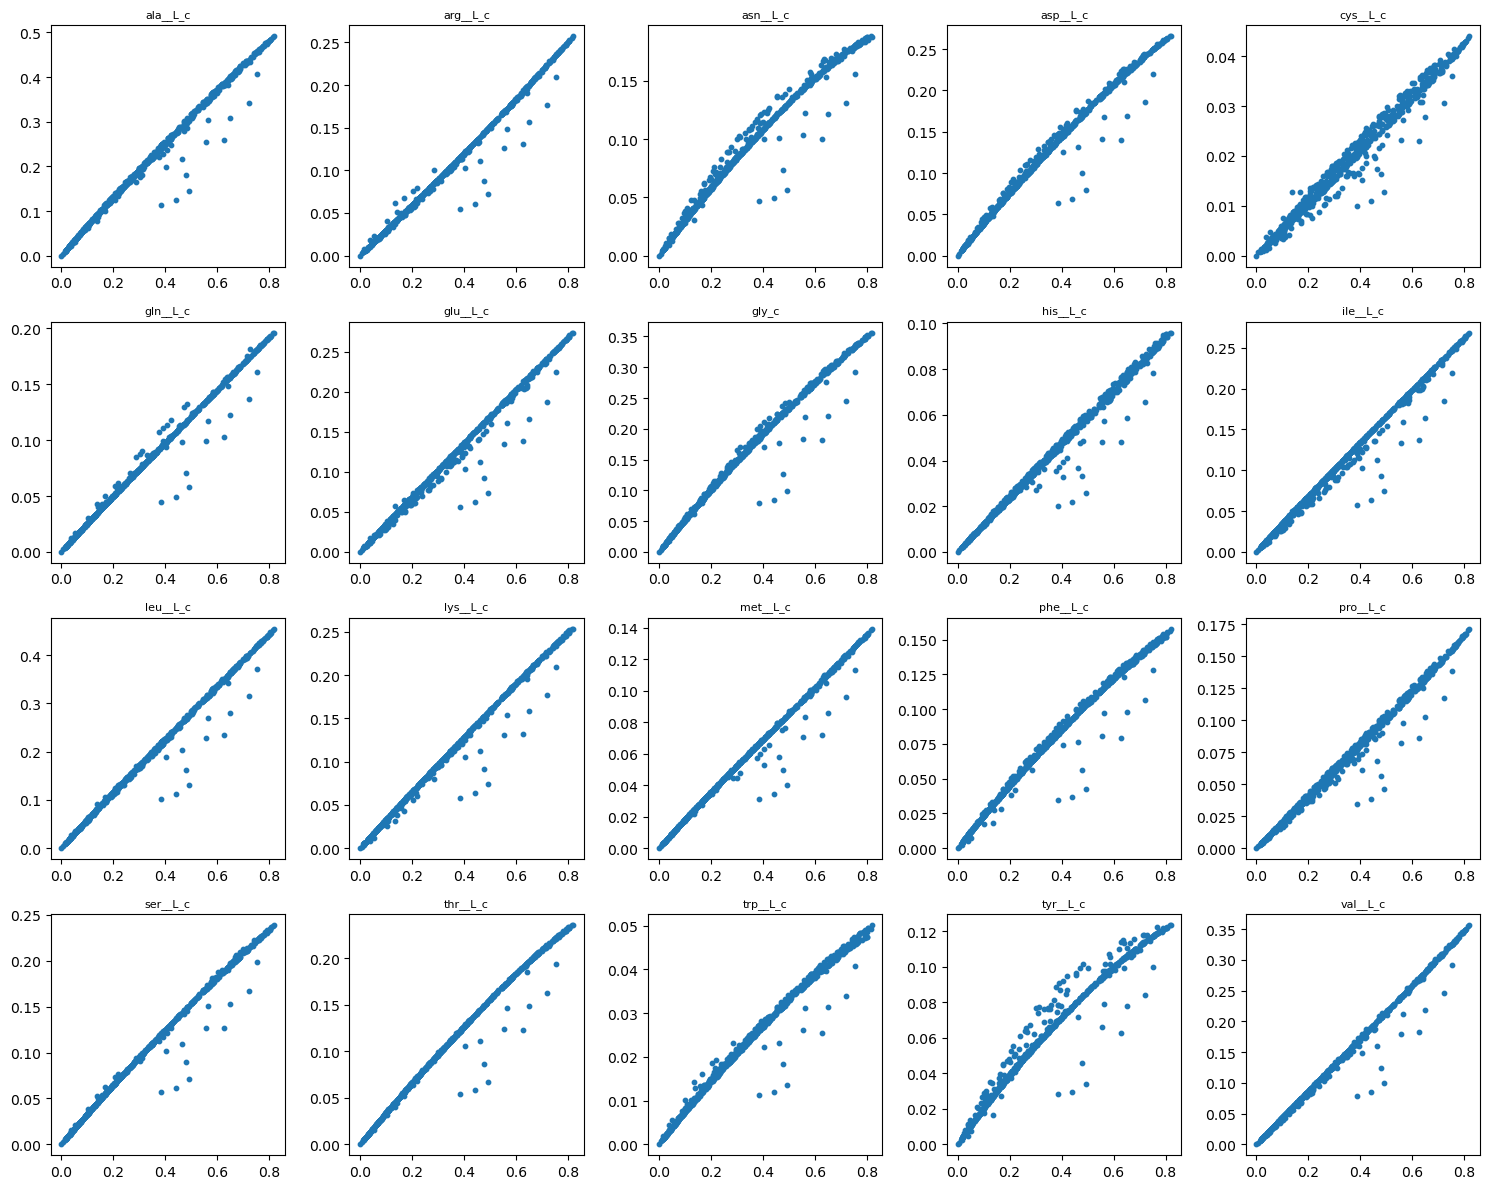

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = glc_transposed.iloc[:, 1]  # reference column

aa_cols = glc_transposed.columns[4:]
n = len(aa_cols)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()

for ax, col in zip(axes, aa_cols):
    ax.scatter(x, glc_transposed[col], s=10)
    ax.set_title(col, fontsize=8)

# remove unused axes
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Sjekker for no3**

In [12]:
no3_samples = prep.get_samples(path='/triumvirate/home/celinaha/LHS_sampling/lhs_no3/results_glc/flux')
no3 = prep.merge_samples(no3_samples, '/triumvirate/home/celinaha/thesis_files/aa_template.csv', substrate='no3_glc')

In [13]:
meta_cols = ["reaction", "amino_acid"]
flux_cols = no3.columns[2:]

# keep first 3 rows separately
first_three = no3.iloc[:3][["reaction", *flux_cols]].copy()
first_three = first_three.rename(columns={"reaction": "feature"})

# charging rows only
charging = no3[no3["reaction"].str.startswith("charging", na=False)].copy()

# extract only amino acid from: generic_tRNA_codon_aminoacid_c
charging["feature"] = charging["amino_acid"].str.replace(
    r"^generic_tRNA_[^_]+_",
    "",
    regex=True
)

# aggregate so each amino acid appears once
aa_agg = (
    charging
    .groupby("feature", as_index=False)[flux_cols]
    .sum()
)

# combine first 3 reactions + amino acids
combined = pd.concat(
    [first_three[["feature", *flux_cols]], aa_agg],
    ignore_index=True
)

# transpose: FBA simulations as rows, features as columns
no3_transposed = (
    combined
    .set_index("feature")
    .T
    .reset_index()
    .rename(columns={"index": "sample"})
)

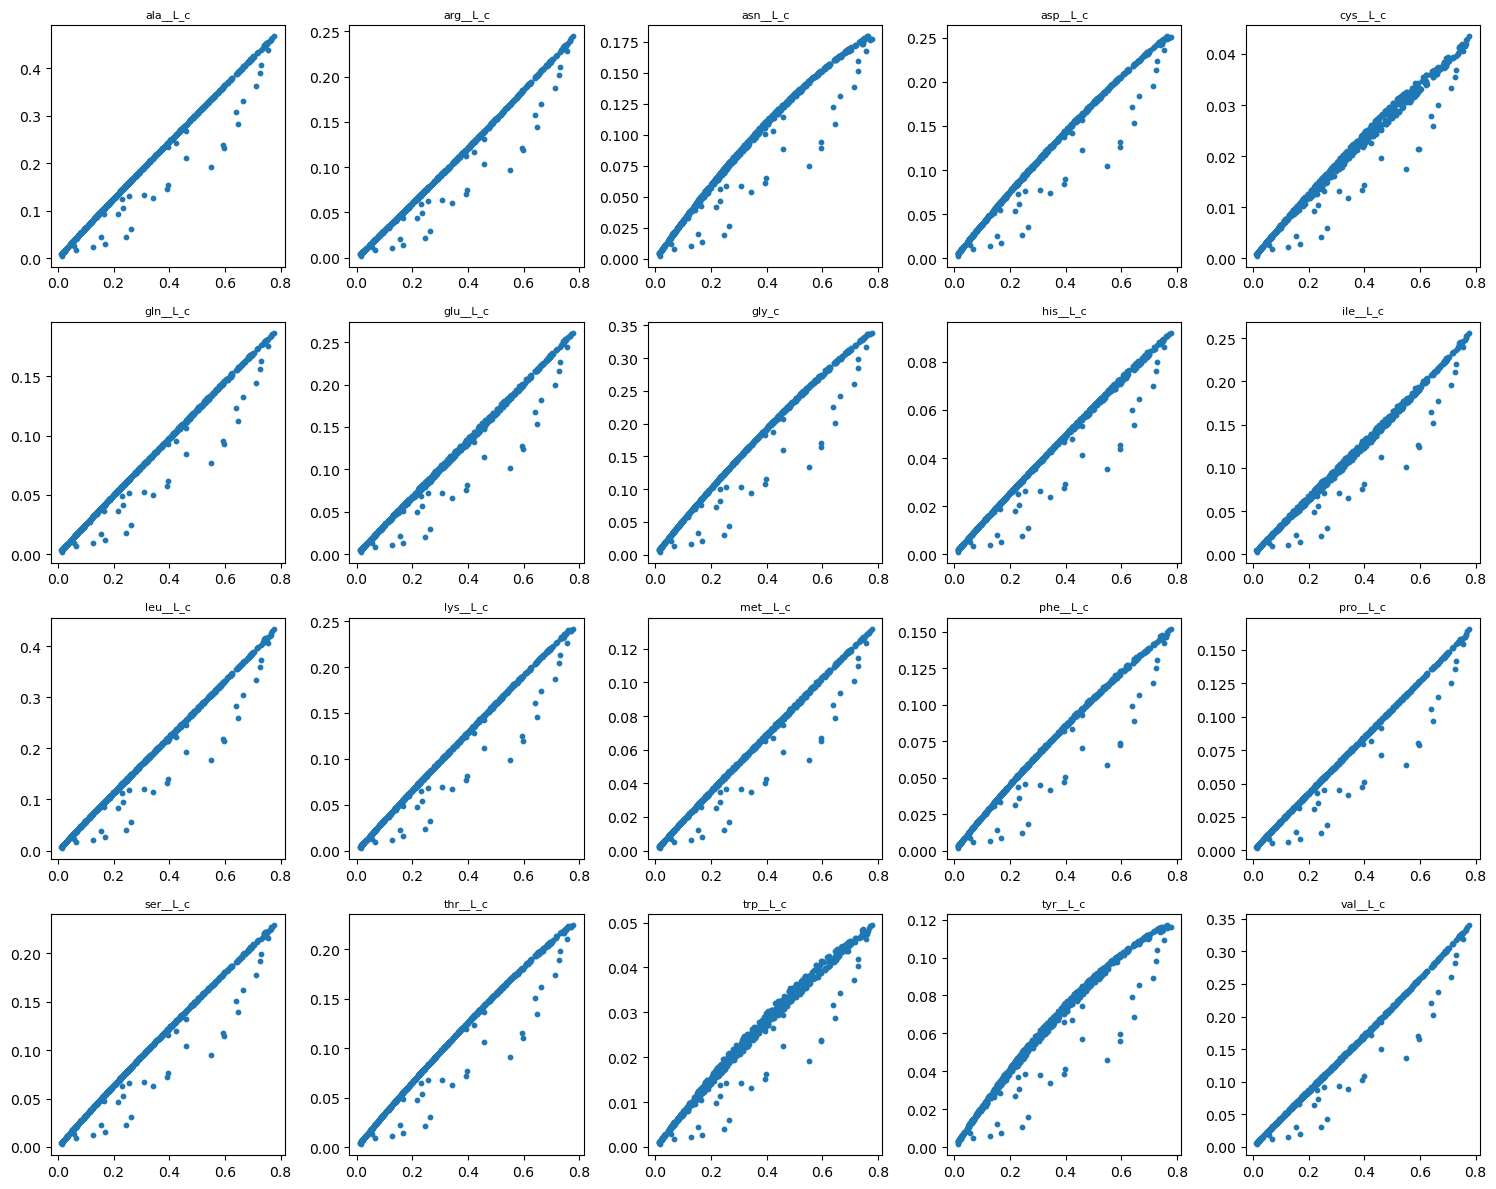

In [15]:
x = no3_transposed.iloc[:, 1]  # reference column

aa_cols = no3_transposed.columns[4:]
n = len(aa_cols)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()

for ax, col in zip(axes, aa_cols):
    ax.scatter(x, no3_transposed[col], s=10)
    ax.set_title(col, fontsize=8)

# remove unused axes
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()